# Sentiment Analysis Pipeline (Tier 1 & Tier 4)




## 1. Environment Setup

Install required packages and load all imports in one place.


In [ ]:
!pip -q install transformers accelerate sentencepiece
!pip install -q vaderSentiment
!pip install -q google-genai
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00


In [ ]:
import bz2
import os
import re
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from tqdm.auto import tqdm
from google import genai
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 2. Tier 1 — VADER Baseline

###  Data Loading and Tier 1 Preparation

# Tier 1 - Vadar

In [ ]:
sentiment_data = []
with bz2.open("test.ft.txt.bz2", "rt", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split(' ', 1)
        if len(parts) == 2:
            label_raw = parts[0]
            text = parts[1]

            if label_raw == '__label__1':
                sentiment = 0
            elif label_raw == '__label__2':
                sentiment = 1
            else:
                continue

            sentiment_data.append({"text": text, "sentiment": sentiment})
        elif line.strip():
            print(f"Skipping malformed line: {line.strip()}")

df_test = pd.DataFrame(sentiment_data)
df_test["text"] = df_test["text"].astype(str)
df_test["sentiment"] = df_test["sentiment"].astype(str)

print(df_test.shape)
df_test.head()

(400000, 2)


,text,sentiment
0,Great CD: My lovely Pat has one of the GREAT v...,1
1,One of the best game music soundtracks - for a...,1
2,Batteries died within a year ...: I bought thi...,0
3,"works fine, but Maha Energy is better: Check o...",1
4,Great for the non-audiophile: Reviewed quite a...,1


### VADER Inference

In [ ]:
analyzer = SentimentIntensityAnalyzer()
def analyze_vader(text):
    label = 1 if score >= 0.05 else 0
    return pd.Series([label, score])

print("Running VADER on test data...")
df_test[['VADER_Pred', 'VADER_Score']] = df_test['text'].apply(analyze_vader)

print("Done! Here are the first 5 results:")
print(df_test[['text', 'VADER_Pred', 'VADER_Score']].head())

Running VADER on test data...
Done! Here are the first 5 results:
                                                text  VADER_Pred  VADER_Score
0  Great CD: My lovely Pat has one of the GREAT v...         1.0       0.9642
1  One of the best game music soundtracks - for a...         1.0       0.9082
2  Batteries died within a year ...: I bought thi...         1.0       0.7297
3  works fine, but Maha Energy is better: Check o...         1.0       0.8945
4  Great for the non-audiophile: Reviewed quite a...         1.0       0.8388


###  Tier 1 Evaluation

In [ ]:
df_test['sentiment'] = pd.to_numeric(df_test['sentiment'])

accuracy = accuracy_score(df_test['sentiment'], df_test['VADER_Pred'])

precision, recall, f1, _ = precision_recall_fscore_support(
    df_test['sentiment'], df_test['VADER_Pred'], average='binary', pos_label=1
)

print(f"VADER Accuracy: {accuracy:.4f}")
print(f"VADER Precision: {precision:.4f}")
print(f"VADER Recall: {recall:.4f}")
print(f"VADER F1-Score: {f1:.4f}")


VADER Accuracy: 0.7237
VADER Precision: 0.6592
VADER Recall: 0.9260
VADER F1-Score: 0.7702


In [ ]:
os.makedirs("results", exist_ok=True)
df_test[["text", "sentiment", "VADER_Pred", "VADER_Score"]].to_csv(
    "results/pred_vader.csv", index=False
)
print("✅ VADER predictions saved to results/pred_vader.csv")


✅ VADER predictions saved to results/pred_vader.csv


# 3. Tier 4 — Local and Cloud LLM Pipeline

###  BERT Residual Error Input Preparation

In [ ]:
df = pd.read_csv("BERT_errors.csv")
rename_map = {}
if "review_text" in df.columns:
    rename_map["review_text"] = "text"
elif "text_clean" in df.columns:
    rename_map["text_clean"] = "text"
if "sentiment" in df.columns:
    rename_map["sentiment"] = "true_label"
if "predicted_label" in df.columns:
    rename_map["predicted_label"] = "bert_pred"

df = df.rename(columns=rename_map)

df = df[df["true_label"] != df["bert_pred"]]
df.head()


,text,true_label,bert_pred,review_length
0,SOY UN APASIONADO DEL BOX: Y ESTE LIBRO ESTÁ E...,2,1,42
1,"Light reading, light in substance: A clichéd s...",1,2,164
2,Great Beginning...poor ending: Parricia Corwel...,2,1,38
3,A historical gem whose title obscures its inte...,1,2,92
4,Had to return it: The sizing is perfect and a ...,1,2,132


In [ ]:
label_map = {
    1: "negative",
    2: "positive",
    "1": "negative",
    "2": "positive"
}

df["true_label"] = df["true_label"].map(label_map)
df["bert_pred"]  = df["bert_pred"].map(label_map)

print("Label distribution after mapping:")
print(df["true_label"].value_counts())


Label distribution after mapping:
true_label
negative    11720
positive    10635
Name: count, dtype: int64


In [ ]:
TIER4_N = 2000

df_input = df.sample(min(TIER4_N, len(df)), random_state=42).reset_index(drop=True)
df_input["row_id"] = range(len(df_input))

print(df_input.shape)

(2000, 5)


###  Small Local Models — TinyLlama and Phi-3

In [ ]:
TINY_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tok_tiny = AutoTokenizer.from_pretrained(TINY_MODEL)
mdl_tiny = AutoModelForCausalLM.from_pretrained(
    TINY_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
PHI_MODEL = "microsoft/Phi-3-mini-4k-instruct"

tok_phi = AutoTokenizer.from_pretrained(PHI_MODEL)
mdl_phi = AutoModelForCausalLM.from_pretrained(
    PHI_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [ ]:
PROMPT = """
Classify the sentiment of this customer review.

Respond with ONLY one word:

positive
or
negative

Review:
{review}

Answer:
"""

In [ ]:
def extract_generated_answer(full_text):
    parts = full_text.rsplit("Answer:", 1)
    return parts[-1].strip().lower()

In [ ]:
def extract_label(answer_text):
    if "positive" in answer_text and "negative" not in answer_text:
        return "positive"
    if "negative" in answer_text and "positive" not in answer_text:
        return "negative"

    if "positive sentiment" in answer_text:
        return "positive"
    if "negative sentiment" in answer_text:
        return "negative"

    match = re.search(r"\b(positive|negative)\b", answer_text)
    return match.group(1) if match else None

In [ ]:
def predict_llm(tokenizer, model, text):
    prompt = PROMPT.format(review=str(text)[:600])

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=4,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    answer = extract_generated_answer(decoded)
    label = extract_label(answer)

    return label

In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

print("Running TinyLlama inference...")
df_input["tinyllama_pred"] = df_input["text"].progress_apply(
    lambda x: predict_llm(tok_tiny, mdl_tiny, x)
)

print("Running Phi-3 inference...")
df_input["phi3_pred"] = df_input["text"].progress_apply(
    lambda x: predict_llm(tok_phi, mdl_phi, x)
)

df_input.head()


Running TinyLlama inference...


  0%|          | 0/2000 [00:00<?, ?it/s]

Running Phi-3 inference...


  0%|          | 0/2000 [00:00<?, ?it/s]

,text,true_label,bert_pred,review_length,row_id,tinyllama_pred,phi3_pred
0,EA Big: I don't know how people could even com...,positive,negative,22,0,positive,negative
1,The book was good overall: It was very good ex...,positive,negative,118,1,positive,negative
2,Quick fix: I love our vet I just keep in case ...,negative,positive,24,2,positive,positive
3,Ties up loose ends: I gave it five stars becau...,positive,negative,90,3,positive,negative
4,Get Amazon's instead: If you purchase from mic...,positive,negative,28,4,positive,positive


In [ ]:
os.makedirs("results", exist_ok=True)
df_input.to_csv("results/tier4_local_llm_predictions.csv", index=False)

###  Local Model Recovery Metrics

In [ ]:
def recovery_rate(true, pred):
    return (true == pred).mean()

tiny_recovery = recovery_rate(df_input["true_label"], df_input["tinyllama_pred"])
phi_recovery  = recovery_rate(df_input["true_label"], df_input["phi3_pred"])

print("TinyLlama recovery:", round(tiny_recovery, 3))
print("Phi-3 recovery:", round(phi_recovery, 3))

TinyLlama recovery: 0.43
Phi-3 recovery: 0.572


In [ ]:
def metrics(true, pred):
    acc = accuracy_score(true, pred)
    p, r, f1, _ = precision_recall_fscore_support(
        true, pred, average="binary", pos_label="positive", zero_division=0
    )
    return acc, p, r, f1

rows = []
for model in ["tinyllama_pred", "phi3_pred"]:
    filtered_df = df_input[df_input[model].notna()]
    if not filtered_df.empty:
        acc, p, r, f1 = metrics(filtered_df["true_label"], filtered_df[model])
        rows.append([model, acc, p, r, f1])
    else:
        rows.append([model, 0.0, 0.0, 0.0, 0.0])

metrics_df = pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1"])
metrics_df

,Model,Accuracy,Precision,Recall,F1
0,tinyllama_pred,0.468120,0.46589,0.984760,0.632530
1,phi3_pred,0.574297,0.57754,0.346524,0.433155


In [ ]:
os.makedirs("errors", exist_ok=True)
tiny_errors = df_input[df_input["tinyllama_pred"] != df_input["true_label"]]
phi_errors  = df_input[df_input["phi3_pred"]  != df_input["true_label"]]

tiny_errors.to_csv("errors/tinyllama_residual.csv", index=False)
phi_errors.to_csv("errors/phi3_residual.csv", index=False)

print("Residual error files saved.")

Residual error files saved.


In [ ]:
bert_error_count = len(df_input)
tiny_fixed = (df_input["true_label"] == df_input["tinyllama_pred"]).sum()
phi_fixed  = (df_input["true_label"] == df_input["phi3_pred"]).sum()

print("TinyLlama fixed:", tiny_fixed, "errors")
print("Phi-3 fixed:", phi_fixed, "errors")

TinyLlama fixed: 859 errors
Phi-3 fixed: 1144 errors


In [ ]:
print("Tiny residual errors:", 1 - tiny_recovery)
print("Phi residual errors:", 1 - phi_recovery)

Tiny residual errors: 0.5705
Phi residual errors: 0.42800000000000005


## Open-Source LLM — Mistral

In [ ]:
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Define quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=torch.float16
)

print("✅ Mistral loaded")

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ Mistral loaded


In [ ]:
def predict_mistral_sentiment(review):
    prompt = f"""\
Classify the sentiment of this customer review.

Return ONLY one word:
positive OR negative

Review:
{review}

Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_len = inputs["input_ids"].shape[1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=5,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    new_tokens = outputs[0][input_len:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

    if "positive" in text:
        return "positive"
    elif "negative" in text:
        return "negative"
    else:
        return None


In [ ]:
df_open = df_input.copy()

df_open["mistral_pred"] = df_open["text"].apply(predict_mistral_sentiment)

print("Done")

Done


In [ ]:
valid = df_open["mistral_pred"].notna()

y_true = df_open.loc[valid, "true_label"]
y_pred = df_open.loc[valid, "mistral_pred"]

print("Recovery:", (y_true == y_pred).mean())
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, pos_label="positive"))
print("Recall:", recall_score(y_true, y_pred, pos_label="positive"))
print("F1:", f1_score(y_true, y_pred, pos_label="positive"))

Recovery: 0.6717325227963525
Accuracy: 0.6717325227963525
Precision: 0.6429699842022117
Recall: 0.6639477977161501
F1: 0.6532905296950241


##  Closed-Source LLM — Gemini

In [ ]:
# I removed my api key for security purposes
os.environ["GEMINI_API_KEY"] = ""


In [ ]:
MODEL_NAME = "gemini-2.5-flash"
BERT_ERROR_PATH = "BERT_errors.csv"
OUT_PATH = "results/tier4_gemini_on_bert_errors.csv"

N_SAMPLES = 300
SLEEP_S = 2.0
MAX_RETRIES = 6
MAX_CHARS = 900

RANDOM_SEED = 42

In [ ]:
df_input = pd.read_csv(BERT_ERROR_PATH)

rename_map = {
    "review_text": "text",
    "text_clean": "text",
    "predicted_label": "bert_pred",
    "predicted": "bert_pred"
}
df_input = df_input.rename(columns={k:v for k,v in rename_map.items() if k in df_input.columns})

required = ["text", "true_label", "bert_pred"]
missing = [c for c in required if c not in df_input.columns]
if missing:
    raise ValueError(f"Missing columns in {BERT_ERROR_PATH}: {missing}. Found: {df_input.columns.tolist()}")

df_input["text"] = df_input["text"].astype(str)

In [ ]:
df_input = df_input.sample(min(N_SAMPLES, len(df_input)), random_state=RANDOM_SEED).reset_index(drop=True)
df_input["row_id"] = range(len(df_input))
print("Running Gemini on:", len(df_input), "BERT-failed samples")

Running Gemini on: 300 BERT-failed samples


In [ ]:
client = genai.Client()

PROMPT = """You are a strict sentiment classifier.

Return EXACTLY one word:
positive OR negative

Review:
{review}

Answer:
"""

def extract_label_strict(raw: str):

    t = (raw or "").strip().lower()
    matches = re.findall(r"\b(positive|negative)\b", t)
    return matches[-1] if matches else None

In [ ]:
def call_gemini(review: str):
    prompt = PROMPT.format(review=str(review)[:MAX_CHARS])

    wait = 1.8
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt,
                config={"temperature": 0, "max_output_tokens": 5}
            )
            raw = (resp.text or "").strip()
            label = extract_label_strict(raw)
            return label, raw
        except Exception as e:
            sleep_s = min(wait + random.random(), 20)
            print(f"[Gemini] retry {attempt}/{MAX_RETRIES} after {sleep_s:.1f}s ({type(e).__name__})")
            time.sleep(sleep_s)
            wait = min(wait * 1.7, 20)

    return None, "ERROR:max_retries"

In [ ]:
preds, raws = [], []

for txt in tqdm(df_input["text"]):
    lab, raw = call_gemini(txt)
    preds.append(lab)
    raws.append(raw)
    time.sleep(SLEEP_S)

df_input["gemini_pred"] = preds
df_input["gemini_raw"] = raws

coverage = df_input["gemini_pred"].notna().mean()
print("Gemini coverage:", round(coverage, 3))

df_input.to_csv(OUT_PATH, index=False)
print("✅ Saved:", OUT_PATH)

  0%|          | 0/300 [00:00<?, ?it/s]

Gemini coverage: 0.993
✅ Saved: results/tier4_gemini_on_bert_errors.csv


In [ ]:
# Evaluate only rows where Gemini produced a label
df_eval = df_input.dropna(subset=["gemini_pred"]).copy()

label_map = {
    1: "negative",
    2: "positive",
    "1": "negative",
    "2": "positive"
}
df_eval["true_label"] = df_eval["true_label"].map(label_map)

recovery = (df_eval["gemini_pred"] == df_eval["true_label"]).mean()

acc = accuracy_score(df_eval["true_label"], df_eval["gemini_pred"])
prec = precision_score(df_eval["true_label"], df_eval["gemini_pred"], pos_label="positive", zero_division=0)
rec = recall_score(df_eval["true_label"], df_eval["gemini_pred"], pos_label="positive", zero_division=0)
f1 = f1_score(df_eval["true_label"], df_eval["gemini_pred"], pos_label="positive", zero_division=0)

print("\n=== GEMINI ON BERT-FAILED (Tier-4 Closed) ===")
print("Recovery:", round(recovery, 3))
print("Accuracy:", round(acc, 3))
print("Precision:", round(prec, 3))
print("Recall:", round(rec, 3))
print("F1:", round(f1, 3))


=== GEMINI ON BERT-FAILED (Tier-4 Closed) ===
Recovery: 0.644
Accuracy: 0.644
Precision: 0.674
Recall: 0.426
F1: 0.523


In [ ]:
metrics_row = pd.DataFrame([
    {
        "Model": "Gemini (closed) on BERT-failed",
        "N": len(df_eval),
        "Coverage": coverage,
        "Recovery": recovery,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }
])

os.makedirs("tables", exist_ok=True)
metrics_row.to_csv("tables/tier4_gemini_metrics_row.csv", index=False)
metrics_row

,Model,N,Coverage,Recovery,Accuracy,Precision,Recall,F1
0,Gemini (closed) on BERT-failed,298,0.993333,0.644295,0.644295,0.674419,0.426471,0.522523


###  Unified Tier 4 Evaluation and Agreement Analysis

In [ ]:
def evaluate(df, col):
    dfv = df[df[col].notna()]
    y_true = dfv["true_label"]
    y_pred = dfv[col]

    return {
        "Coverage_%": round(len(dfv)/len(df)*100,2),
        "Recovery_%": round((y_true==y_pred).mean()*100,2),
        "Accuracy_%": round(accuracy_score(y_true,y_pred)*100,2),
        "Precision_%": round(precision_score(y_true,y_pred,pos_label="positive",zero_division=0)*100,2),
        "Recall_%": round(recall_score(y_true,y_pred,pos_label="positive",zero_division=0)*100,2),
        "F1_%": round(f1_score(y_true,y_pred,pos_label="positive",zero_division=0)*100,2)
    }

In [ ]:
df_input = pd.read_csv("results/tier4_local_llm_predictions.csv")

_gemini_out = pd.read_csv(OUT_PATH)[["row_id", "gemini_pred"]]
df_input = df_input.merge(_gemini_out, on="row_id", how="left")

valid_tp = df_input["tinyllama_pred"].notna() & df_input["phi3_pred"].notna()
agree_tiny_phi = (df_input.loc[valid_tp, "tinyllama_pred"] == df_input.loc[valid_tp, "phi3_pred"]).mean()

valid_tg = df_input["tinyllama_pred"].notna() & df_input["gemini_pred"].notna()
agree_tiny_gem = (df_input.loc[valid_tg, "tinyllama_pred"] == df_input.loc[valid_tg, "gemini_pred"]).mean()

valid_pg = df_input["phi3_pred"].notna() & df_input["gemini_pred"].notna()
agree_phi_gem = (df_input.loc[valid_pg, "phi3_pred"] == df_input.loc[valid_pg, "gemini_pred"]).mean()

df_input["mistral_pred"] = df_input["text"].apply(predict_mistral_sentiment)

valid_mg = df_input["mistral_pred"].notna() & df_input["gemini_pred"].notna()
agree_mistral_gem = (df_input.loc[valid_mg, "mistral_pred"] == df_input.loc[valid_mg, "gemini_pred"]).mean()

agree_table = pd.DataFrame([
    {"Pair": "TinyLlama vs Phi-3", "Agreement": agree_tiny_phi},
    {"Pair": "TinyLlama vs Gemini", "Agreement": agree_tiny_gem},
    {"Pair": "Phi-3 vs Gemini", "Agreement": agree_phi_gem},
    {"Pair": "Mistral vs Gemini", "Agreement": agree_mistral_gem}
])

agree_table["Agreement_%"] = (agree_table["Agreement"] * 100).round(2)
agree_table


,Pair,Agreement,Agreement_%
0,TinyLlama vs Phi-3,0.297209,29.72
1,TinyLlama vs Gemini,0.302491,30.25
2,Phi-3 vs Gemini,0.842282,84.23
3,Mistral vs Gemini,0.886700,88.67


In [ ]:
agree_table.to_csv("tables/tier4_llm_agreement.csv", index=False)
print("✅ Saved: tables/tier4_llm_agreement.csv")

✅ Saved: tables/tier4_llm_agreement.csv


###  Recovery Overlap and Merged Evaluation Dataset

In [ ]:
def recovered_mask(pred_col):
    return df_input[pred_col].notna() & (df_input[pred_col] == df_input["true_label"])

m_tiny = recovered_mask("tinyllama_pred")
m_phi  = recovered_mask("phi3_pred")
m_gem  = recovered_mask("gemini_pred")

overlap = pd.DataFrame([{
    "Recovered_by_Tiny_only": int((m_tiny & ~m_phi & ~m_gem).sum()),
    "Recovered_by_Phi_only": int((~m_tiny & m_phi & ~m_gem).sum()),
    "Recovered_by_Gemini_only": int((~m_tiny & ~m_phi & m_gem).sum()),
    "Recovered_by_All_3": int((m_tiny & m_phi & m_gem).sum()),
    "Recovered_by_Tiny_and_Phi": int((m_tiny & m_phi & ~m_gem).sum()),
    "Recovered_by_Tiny_and_Gem": int((m_tiny & ~m_phi & m_gem).sum()),
    "Recovered_by_Phi_and_Gem": int((~m_tiny & m_phi & m_gem).sum()),
    "Not_recovered_by_any": int((~m_tiny & ~m_phi & ~m_gem).sum()),
}])

overlap

,Recovered_by_Tiny_only,Recovered_by_Phi_only,Recovered_by_Gemini_only,Recovered_by_All_3,Recovered_by_Tiny_and_Phi,Recovered_by_Tiny_and_Gem,Recovered_by_Phi_and_Gem,Not_recovered_by_any
0,524,713,13,35,276,24,120,295


In [ ]:
local_path  = "results/tier4_local_llm_predictions.csv"
gemini_path = "results/tier4_gemini_on_bert_errors.csv"

df_local  = pd.read_csv(local_path)
df_gemini = pd.read_csv(gemini_path)

print("Local rows:", len(df_local))
print("Gemini rows:", len(df_gemini))


Local rows: 2000
Gemini rows: 300


In [ ]:
print(df_local.columns)
print(df_gemini.columns)

Index(['text', 'true_label', 'bert_pred', 'review_length', 'row_id',
       'tinyllama_pred', 'phi3_pred'],
      dtype='object')
Index(['text', 'true_label', 'bert_pred', 'review_length', 'row_id',
       'gemini_pred', 'gemini_raw'],
      dtype='object')


In [ ]:
df_all = df_local.merge(
    df_gemini[["row_id", "gemini_pred"]],
    on="row_id",
    how="left"
)

print("Merged rows:", len(df_all))
df_all.head()

Merged rows: 2000


,text,true_label,bert_pred,review_length,row_id,tinyllama_pred,phi3_pred,gemini_pred
0,EA Big: I don't know how people could even com...,positive,negative,22,0,positive,negative,negative
1,The book was good overall: It was very good ex...,positive,negative,118,1,positive,negative,negative
2,Quick fix: I love our vet I just keep in case ...,negative,positive,24,2,positive,positive,positive
3,Ties up loose ends: I gave it five stars becau...,positive,negative,90,3,positive,negative,negative
4,Get Amazon's instead: If you purchase from mic...,positive,negative,28,4,positive,positive,negative


In [ ]:
df_all["mistral_pred"] = df_all["text"].apply(predict_mistral_sentiment)

print("TinyLlama:", df_all["tinyllama_pred"].notna().sum())
print("Phi-3:", df_all["phi3_pred"].notna().sum())
print("Mistral:", df_all["mistral_pred"].notna().sum())
print("Gemini:", df_all["gemini_pred"].notna().sum())

TinyLlama: 1835
Phi-3: 1992
Mistral: 1316
Gemini: 298


###  Tier 4 Model Comparison Table

In [ ]:
models_to_evaluate = [
    ("TinyLlama (small)", "tinyllama_pred"),
    ("Phi-3 (small)", "phi3_pred"),
    ("Mistral (open)", "mistral_pred"),
    ("Gemini (closed)", "gemini_pred")
]

matched_results = []
for name, col in models_to_evaluate:
    if df_all[col].notna().sum() > 0:

        temp_df_for_eval = df_all.copy()
        temp_df_for_eval["predicted_label"] = temp_df_for_eval[col]

        res = evaluate(temp_df_for_eval, "predicted_label")
        res["Model"] = name
        res["Coverage"] = df_all[col].notna().sum()
        res["Errors Fixed"] = (df_all[col] == df_all["true_label"]).sum()
        matched_results.append(res)
    else:
        matched_results.append({"Model": name, "Coverage": 0, "Coverage_%": 0.0, "Errors Fixed": 0, "Recovery_%": 0.0, "Accuracy_%": 0.0, "Precision_%": 0.0, "Recall_%": 0.0, "F1_%": 0.0})

matched_table = pd.DataFrame(matched_results)

matched_table.to_csv("/content/tier4_full_comparison.csv", index=False)
matched_table.to_csv("/content/tier4_matched_comparison.csv", index=False)

print("Saved tier4_full_comparison.csv and tier4_matched_comparison.csv")

Saved tier4_full_comparison.csv and tier4_matched_comparison.csv


In [ ]:
matched_table.sort_values("Recovery_%", ascending=False)

,Coverage_%,Recovery_%,Accuracy_%,Precision_%,Recall_%,F1_%,Model,Coverage,Errors Fixed
2,65.80,67.17,67.17,64.30,66.39,65.33,Mistral (open),1316,884
3,14.90,64.43,64.43,67.44,42.65,52.25,Gemini (closed),298,192
1,99.60,57.43,57.43,57.75,34.65,43.32,Phi-3 (small),1992,1144
0,91.75,46.81,46.81,46.59,98.48,63.25,TinyLlama (small),1835,859


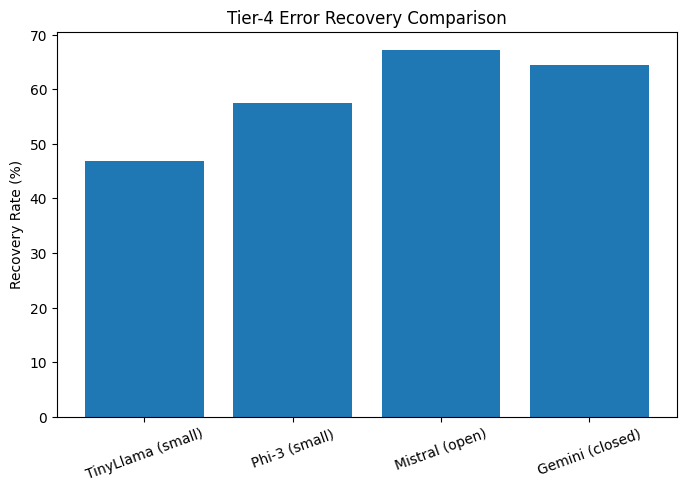

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(matched_table["Model"], matched_table["Recovery_%"])
plt.ylabel("Recovery Rate (%)")
plt.title("Tier-4 Error Recovery Comparison")
plt.xticks(rotation=20)
plt.show()

## 4. Error Taxonomy and Diagnostic Analysis

In [ ]:
OUT_DIR = "tables_tier14_on_bert_errors_per_model"
os.makedirs(OUT_DIR, exist_ok=True)

NEGATION_RE = re.compile(
    r"\b(?:not|never|no|hardly|without|"
    r"can't|cannot|won't|don't|doesn't|didn't|isn't|aren't|wasn't|weren't|"
    r"shouldn't|couldn't|wouldn't|mustn't|n't)\b",
    re.IGNORECASE
)
CONTRAST_RE = re.compile(
    r"\b(?:but|however|although|though|yet|still|nevertheless|nonetheless|whereas|while)\b",
    re.IGNORECASE
)
SENTI_CUE_RE = re.compile(
    r"\b(?:good|great|excellent|amazing|awesome|love|loved|like|liked|best|perfect|fantastic|wonderful|recommend|"
    r"bad|terrible|awful|worst|hate|hated|poor|disappoint|disappointed|broken|waste|useless|refund|return|problem|issues|"
    r"annoying|horrible|garbage)\b",
    re.IGNORECASE
)
AMBIGUOUS_DESC_RE = re.compile(
    r"\b(?:unpredictable|light|cold|cheap|heavy|hot|tight|loose|small|large|thin|thick|loud|quiet|fine|ok|okay)\b",
    re.IGNORECASE
)
ALLCAPS_WORD_RE = re.compile(r"\b[A-Z]{3,}\b")
EXCESS_PUNCT_RE = re.compile(r"(?:!{2,}|\?{2,}|\.{4,})")
ELONGATED_RE    = re.compile(r"(.)\1{2,}", re.IGNORECASE)

def normalize_label(x) -> str:
    if pd.isna(x): return ""
    s = str(x).strip().lower()
    if s in {"pos", "positive"}: return "positive"
    if s in {"neg", "negative"}: return "negative"
    if s in {"1"}: return "positive"
    if s in {"0", "2"}: return "negative"
    if "positive" in s and "negative" not in s: return "positive"
    if "negative" in s and "positive" not in s: return "negative"
    return s

def detect_noise_formatting(text: str) -> bool:
    t = "" if text is None else str(text)
    return bool(ALLCAPS_WORD_RE.search(t) or EXCESS_PUNCT_RE.search(t) or ELONGATED_RE.search(t))

def tag_error_categories_1_to_6(df: pd.DataFrame,
                                text_col: str = "text",
                                true_col: str = "true_label",
                                pred_col: str = "bert_pred",
                                short_words: int = 5,
                                long_words: int = 100) -> pd.DataFrame:
    df = df.copy()
    required = {text_col, true_col, pred_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}. Found: {df.columns.tolist()}")
    df[text_col] = df[text_col].astype(str).fillna("")
    df[true_col] = df[true_col].fillna('').map(normalize_label)
    df[pred_col] = df[pred_col].fillna('').map(normalize_label)
    df["word_count"] = df[text_col].str.count(r"\S+")
    df["cat1_negation_sensitivity"] = df[text_col].str.contains(NEGATION_RE, na=False)
    df["cat2_mixed_sentiment"]      = df[text_col].str.contains(CONTRAST_RE, na=False)
    df["cat3_implicit_sentiment"]   = ~df[text_col].str.contains(SENTI_CUE_RE, na=False)
    df["cat4_lexical_ambiguity"]    = df[text_col].str.contains(AMBIGUOUS_DESC_RE, na=False)
    df["cat5a_too_short_lt5"]       = df["word_count"] < short_words
    df["cat5b_too_long_gt100"]      = df["word_count"] > long_words
    df["cat5_length_degradation"]   = df["cat5a_too_short_lt5"] | df["cat5b_too_long_gt100"]
    df["cat6_noise_formatting_bias"]= df[text_col].apply(detect_noise_formatting)
    return df

print("\n--- Running VADER Taxonomy on FULL test dataset (VADER errors only) ---")

df_vader_full_analysis = df_test.copy()

df_vader_full_analysis['true_label'] = df_vader_full_analysis['sentiment'].apply(normalize_label)
df_vader_full_analysis['vader_pred'] = df_vader_full_analysis['VADER_Pred'].apply(normalize_label)

df_vader_full_errors = df_vader_full_analysis[df_vader_full_analysis['true_label'] != df_vader_full_analysis['vader_pred']].copy()

if df_vader_full_errors.empty:
    print("No errors found for VADER on the full test dataset.")
else:
    df_tagged_vader_full = tag_error_categories_1_to_6(
        df_vader_full_errors,
        text_col="text",
        true_col="true_label",
        pred_col="vader_pred"
    )
    total_err_vader_full = len(df_tagged_vader_full)
    counts_vader_full = df_tagged_vader_full[cat_cols].sum().rename(index=lambda x: x.replace("cat", "Category ").replace("_", " "))
    percents_vader_full = (counts_vader_full / total_err_vader_full * 100).round(4)

    vader_full_counts_path = os.path.join(OUT_DIR, "VADER_Full_Tier1_Cat1to6_Counts.csv")
    vader_full_perc_path = os.path.join(OUT_DIR, "VADER_Full_Tier1_Cat1to6_Percent.csv")

    counts_vader_full.to_csv(vader_full_counts_path, header=["Count"])
    percents_vader_full.to_csv(vader_full_perc_path, header=["Percent_%"])
    print(f"✅ VADER (Full Test Set): {total_err_vader_full} errors tagged → {vader_full_counts_path}")

MODEL_PRED_COLS_TAGGING = {
    "VADER_Tier1": "vader_pred",
    "TinyLlama_Tier4_small": "tinyllama_pred",
    "Phi3_Tier4_small":      "phi3_pred",
    "Mistral_Tier4_open":    "mistral_pred",
    "Gemini_Tier4_closed":   "gemini_pred",
}

cat_cols = [
    "cat1_negation_sensitivity", "cat2_mixed_sentiment",
    "cat3_implicit_sentiment",   "cat4_lexical_ambiguity",
    "cat5_length_degradation",   "cat6_noise_formatting_bias"
]

for model_name, pred_col_name_actual in MODEL_PRED_COLS_TAGGING.items():
    if pred_col_name_actual not in df_all.columns:
        print(f"⚠️ Skipping {model_name}: column {pred_col_name_actual} not in df_all")
        continue

    # Filter for errors specific to the current model (pred_col_name_actual)
    df_model_errors = df_all[df_all[pred_col_name_actual].notna() &
                             (df_all[pred_col_name_actual] != df_all["true_label"])].copy()

    if df_model_errors.empty:
        print(f"No errors found for {model_name}")
        continue

    # Pass the actual prediction column name to the tagging function
    df_tagged = tag_error_categories_1_to_6(df_model_errors, text_col="text",
                                             true_col="true_label", pred_col=pred_col_name_actual)
    total_err = len(df_tagged)
    counts  = df_tagged[cat_cols].sum().rename(index=lambda x: x.replace("cat", "Category ").replace("_", " "))
    percents = (counts / total_err * 100).round(4)
    counts_path  = os.path.join(OUT_DIR, f"{model_name}_Cat1to6_Counts.csv")
    perc_path    = os.path.join(OUT_DIR, f"{model_name}_Cat1to6_Percent.csv")
    counts.to_csv(counts_path,  header=["Count"])
    percents.to_csv(perc_path,  header=["Percent_%"])
    print(f"✅ {model_name}: {total_err} errors tagged → {counts_path}")


--- Running VADER Taxonomy on FULL test dataset (VADER errors only) ---
✅ VADER (Full Test Set): 400000 errors tagged → tables_tier14_on_bert_errors_per_model/VADER_Full_Tier1_Cat1to6_Counts.csv
✅ VADER_Tier1: 1172 errors tagged → tables_tier14_on_bert_errors_per_model/VADER_Tier1_Cat1to6_Counts.csv
✅ TinyLlama_Tier4_small: 976 errors tagged → tables_tier14_on_bert_errors_per_model/TinyLlama_Tier4_small_Cat1to6_Counts.csv
✅ Phi3_Tier4_small: 848 errors tagged → tables_tier14_on_bert_errors_per_model/Phi3_Tier4_small_Cat1to6_Counts.csv
✅ Mistral_Tier4_open: 432 errors tagged → tables_tier14_on_bert_errors_per_model/Mistral_Tier4_open_Cat1to6_Counts.csv
✅ Gemini_Tier4_closed: 106 errors tagged → tables_tier14_on_bert_errors_per_model/Gemini_Tier4_closed_Cat1to6_Counts.csv


In [ ]:
# Run VADER on df_input (BERT residuals) so vader_pred column exists
if "vader_pred" not in df_all.columns:
    print("Running VADER on BERT residual errors...")
    def get_vader_label(text):
        score = analyzer.polarity_scores(str(text))["compound"]
        return "positive" if score >= 0.05 else "negative"
    df_all["vader_pred"] = df_all["text"].apply(get_vader_label)
    print("✅ vader_pred column added to df_all")
else:
    print("vader_pred already present")


vader_pred already present


##  Error Analysis — Tier 1 & 4 Summary Tables

In [ ]:
OUT_DIR = "tables_tier14_on_bert_errors_per_model"
MODEL_PRED_COLS = {
    "VADER_Full_Tier1": "vader_pred",
    "TinyLlama_Tier4_small": "tinyllama_pred",
    "Phi3_Tier4_small": "phi3_pred",
    "Mistral_Tier4_open": "mistral_pred",
    "Gemini_Tier4_closed": "gemini_pred",
}

print("### Category 1-6 Taxonomy Analysis for Each Model's Errors ###")

all_counts_dfs = []
all_perc_dfs = []

for model_name, pred_col in MODEL_PRED_COLS.items():
    counts_path = os.path.join(OUT_DIR, f"{model_name}_Cat1to6_Counts.csv")
    perc_path = os.path.join(OUT_DIR, f"{model_name}_Cat1to6_Percent.csv")

    if os.path.exists(counts_path) and os.path.exists(perc_path):
        counts_df = pd.read_csv(counts_path, index_col=0)
        perc_df = pd.read_csv(perc_path, index_col=0)

        counts_df.columns = [f"{model_name}_Count"]
        perc_df.columns = [f"{model_name}_Percent_%"]

        all_counts_dfs.append(counts_df)
        all_perc_dfs.append(perc_df)
    else:
        print(f"\n--- {model_name} ---")
        print(f"Skipping {model_name} as taxonomy files were not generated (likely no errors or column not found).")

if all_counts_dfs:
    final_counts_df = pd.concat(all_counts_dfs, axis=1)
    print("\n### Consolidated Category 1-6 Counts (BERT residual errors) ###")
    display(final_counts_df)

if all_perc_dfs:
    final_perc_df = pd.concat(all_perc_dfs, axis=1)
    print("\n### Consolidated Category 1-6 Percentages (BERT residual errors) ###")
    display(final_perc_df)

### Category 1-6 Taxonomy Analysis for Each Model's Errors ###

### Consolidated Category 1-6 Counts (BERT residual errors) ###


,VADER_Full_Tier1_Count,TinyLlama_Tier4_small_Count,Phi3_Tier4_small_Count,Mistral_Tier4_open_Count,Gemini_Tier4_closed_Count
Category 1 negation sensitivity,275912,616,607,279,75
Category 2 mixed sentiment,213787,607,544,235,62
Category 3 implicit sentiment,83461,241,248,115,30
Category 4 lexical ambiguity,73036,191,170,66,20
Category 5 length degradation,116032,301,260,111,34
Category 6 noise formatting bias,168741,446,395,221,49



### Consolidated Category 1-6 Percentages (BERT residual errors) ###


,VADER_Full_Tier1_Percent_%,TinyLlama_Tier4_small_Percent_%,Phi3_Tier4_small_Percent_%,Mistral_Tier4_open_Percent_%,Gemini_Tier4_closed_Percent_%
Category 1 negation sensitivity,68.9780,63.1148,71.5802,64.5833,70.7547
Category 2 mixed sentiment,53.4468,62.1926,64.1509,54.3981,58.4906
Category 3 implicit sentiment,20.8652,24.6926,29.2453,26.6204,28.3019
Category 4 lexical ambiguity,18.2590,19.5697,20.0472,15.2778,18.8679
Category 5 length degradation,29.0080,30.8402,30.6604,25.6944,32.0755
Category 6 noise formatting bias,42.1853,45.6967,46.5802,51.1574,46.2264


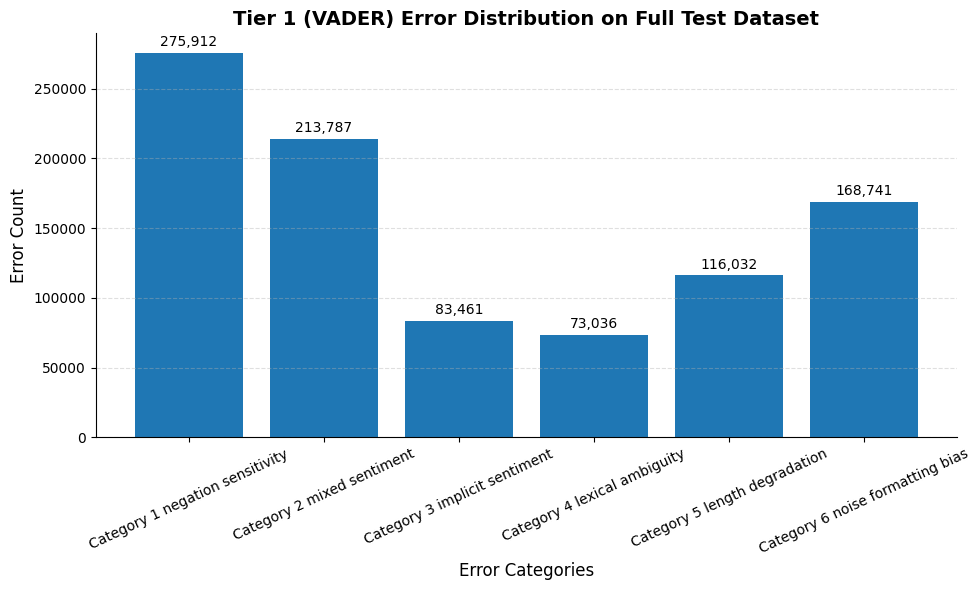

In [ ]:
categories = counts_vader_full.index.tolist()
values = counts_vader_full.values.tolist()

plt.figure(figsize=(10, 6))

bars = plt.bar(categories, values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5000,
        f"{int(height):,}",
        ha="center",
        fontsize=10
    )

plt.title("Tier 1 (VADER) Error Distribution on Full Test Dataset", fontsize=14, weight="bold")
plt.xlabel("Error Categories", fontsize=12)
plt.ylabel("Error Count", fontsize=12)

plt.xticks(rotation=25)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

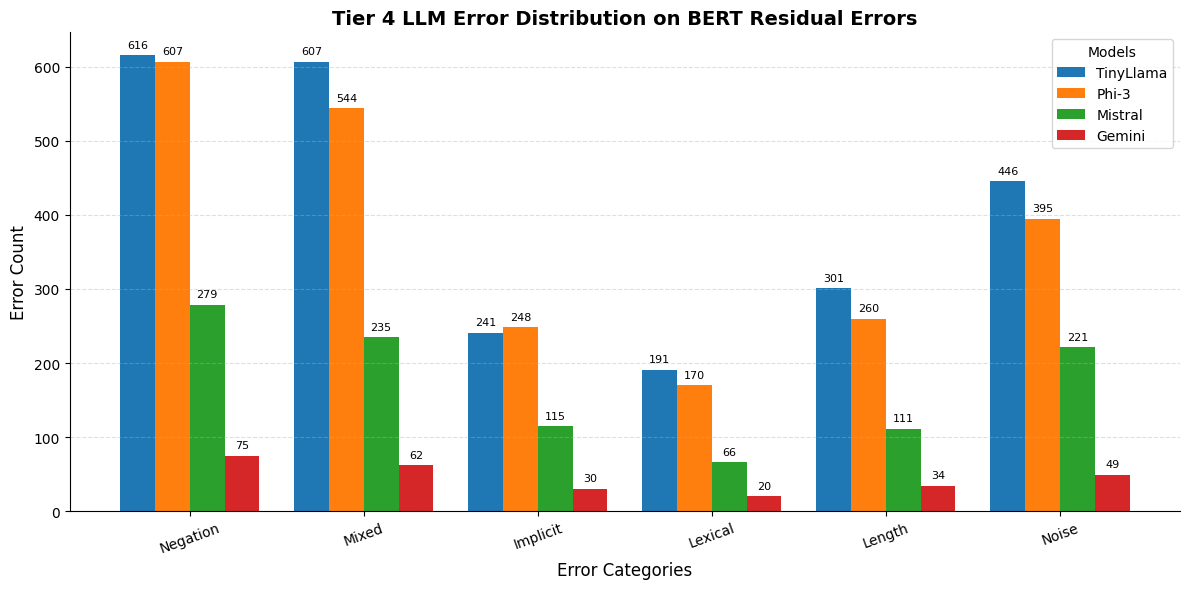

In [ ]:
categories = [
    "Negation",
    "Mixed",
    "Implicit",
    "Lexical",
    "Length",
    "Noise"
]

tiny = [616, 607, 241, 191, 301, 446]
phi  = [607, 544, 248, 170, 260, 395]
mistral = [279, 235, 115, 66, 111, 221]
gemini  = [75, 62, 30, 20, 34, 49]

x = np.arange(len(categories))
width = 0.2
plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - 1.5*width, tiny, width, label="TinyLlama")
bars2 = plt.bar(x - 0.5*width, phi, width, label="Phi-3")
bars3 = plt.bar(x + 0.5*width, mistral, width, label="Mistral")
bars4 = plt.bar(x + 1.5*width, gemini, width, label="Gemini")

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 10,
            f"{int(height)}",
            ha="center",
            fontsize=8
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)
plt.title(
    "Tier 4 LLM Error Distribution on BERT Residual Errors",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Error Categories", fontsize=12)
plt.ylabel("Error Count", fontsize=12)
plt.xticks(x, categories, rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend(title="Models")
plt.tight_layout()
plt.show()

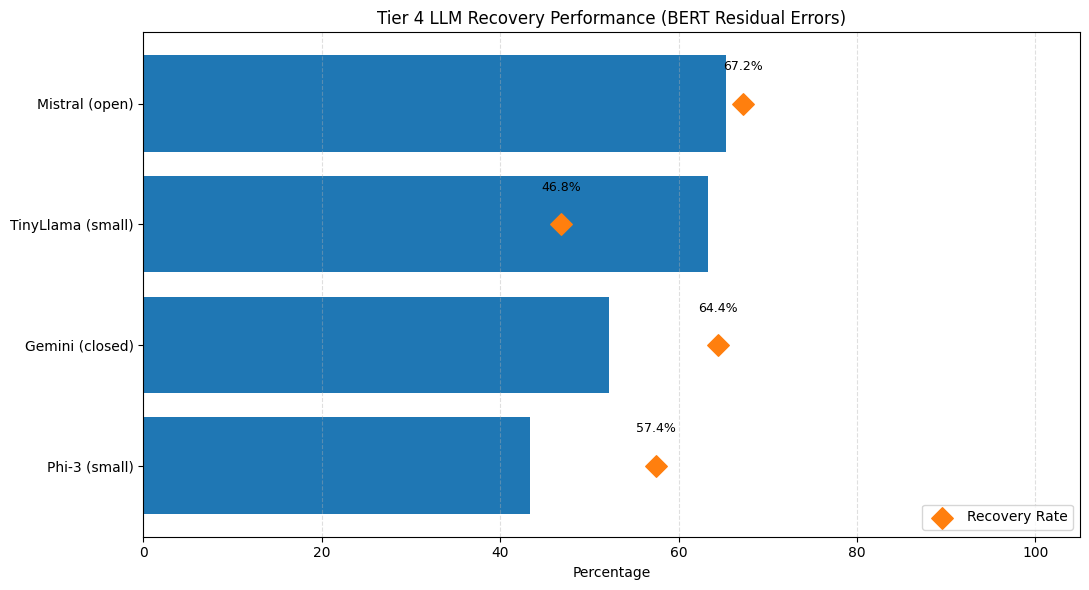

In [ ]:
chart_df = pd.DataFrame([
    {"Model": "Mistral (open)", "Recovery_%": 67.17, "F1_%": 65.33},
    {"Model": "Gemini (closed)", "Recovery_%": 64.43, "F1_%": 52.25},
    {"Model": "Phi-3 (small)", "Recovery_%": 57.43, "F1_%": 43.32},
    {"Model": "TinyLlama (small)", "Recovery_%": 46.81, "F1_%": 63.25},
])
chart_df = chart_df.sort_values("F1_%", ascending=True).reset_index(drop=True)

plt.figure(figsize=(11, 6))

plt.barh(
    chart_df["Model"],
    chart_df["F1_%"]
)
plt.scatter(
    chart_df["Recovery_%"],
    chart_df["Model"],
    marker="D",
    s=120,
    label="Recovery Rate",
    zorder=5
)
for i, row in chart_df.iterrows():
    plt.text(
        row["Recovery_%"],
        i + 0.25,
        f"{row['Recovery_%']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlim(0, 105)
plt.xlabel("Percentage")
plt.title("Tier 4 LLM Recovery Performance (BERT Residual Errors)")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

###  Category 7 Cross-Model Disagreement

In [ ]:
OUT_DIR = "tables_tier14_on_bert_errors"
os.makedirs(OUT_DIR, exist_ok=True)

def normalize_label(x) -> str:
    if pd.isna(x): return ""
    s = str(x).strip().lower()
    if s in {"2", "__label__2", "pos", "positive"}: return "positive"
    if s in {"1", "__label__1", "neg", "negative"}: return "negative"
    return s

def compute_cat7_disagreement(df: pd.DataFrame, pred_cols: list):
    df_copy = df.copy()
    missing = set(pred_cols) - set(df_copy.columns)
    if missing:
        raise ValueError(f"Missing prediction columns: {missing}")
    for c in pred_cols:
        df_copy[c] = df_copy[c].apply(normalize_label)
    df_copy["cat7_cross_model_disagreement"] = df_copy[pred_cols].nunique(axis=1) > 1
    total = len(df_copy)
    disagree_n = int(df_copy["cat7_cross_model_disagreement"].sum())
    disagree_pct = round((disagree_n / total) * 100, 4) if total else 0.0
    summary = pd.DataFrame([{
        "total_reviews": total,
        "disagreement_count": disagree_n,
        "disagreement_percent_%": disagree_pct,
        "models_compared": ", ".join(pred_cols)
    }])
    disagreement_analysis = []
    disagreeing_rows = df_copy[df_copy["cat7_cross_model_disagreement"]].copy()
    for model_col in pred_cols:
        model_name = model_col.replace("_pred", "")
        valid_rows = disagreeing_rows[disagreeing_rows[model_col].notna() &
                                      (disagreeing_rows[model_col] != "")]
        if valid_rows.empty:
            disagreement_analysis.append({"Model": model_name,
                "Total Disagreeing": 0, "Correct in Disagreement": 0,
                "Positive Predictions": 0, "Negative Predictions": 0,
                "Correct Rate %": 0.0})
            continue
        pos_preds = (valid_rows[model_col] == "positive").sum()
        neg_preds = (valid_rows[model_col] == "negative").sum()
        correct   = (valid_rows[model_col] == valid_rows["true_label"]).sum()
        disagreement_analysis.append({
            "Model": model_name,
            "Total Disagreeing": len(valid_rows),
            "Correct in Disagreement": int(correct),
            "Positive Predictions": int(pos_preds),
            "Negative Predictions": int(neg_preds),
            "Correct Rate %": round(correct / len(valid_rows) * 100, 2)
        })
    disagree_df = pd.DataFrame(disagreement_analysis)
    return summary, disagree_df

# Run disagreement analysis across all Tier-4 models
tier4_pred_cols = [c for c in ["tinyllama_pred", "phi3_pred", "mistral_pred", "gemini_pred"]
                   if c in df_all.columns and df_all[c].notna().any()]

if len(tier4_pred_cols) >= 2:
    cat7_summary, cat7_detail = compute_cat7_disagreement(df_all, tier4_pred_cols)
    cat7_summary.to_csv(os.path.join(OUT_DIR, "Cat7_Disagreement_Summary.csv"), index=False)
    cat7_detail.to_csv(os.path.join(OUT_DIR, "Cat7_Disagreement_Detail.csv"), index=False)
    print("✅ Category 7 disagreement analysis complete.")
    display(cat7_summary)
    display(cat7_detail)
else:
    print("⚠️ Not enough model prediction columns to compute disagreement.")


✅ Category 7 disagreement analysis complete.


,total_reviews,disagreement_count,disagreement_percent_%,models_compared
0,2000,1946,97.3,"tinyllama_pred, phi3_pred, mistral_pred, gemin..."


,Model,Total Disagreeing,Correct in Disagreement,Positive Predictions,Negative Predictions,Correct Rate %
0,tinyllama,1781,827,1750,31,46.43
1,phi3,1938,1112,508,1430,57.38
2,mistral,1262,852,580,682,67.51
3,gemini,244,160,33,211,65.57


# 5. Confusion Matrix Analysis

### Confusion Matrix Tier 1

In [ ]:
df_test['sentiment'] = pd.to_numeric(df_test['sentiment'])
df_test['VADER_Pred'] = pd.to_numeric(df_test['VADER_Pred'])
cm_vader = confusion_matrix(df_test['sentiment'], df_test['VADER_Pred'], labels=[0, 1])

tn_vader, fp_vader, fn_vader, tp_vader = cm_vader.ravel()

vader_cm_table = pd.DataFrame([
    {
        "Model": "VADER (Tier 1)",
        "True Negative (TN)": tn_vader,
        "False Positive (FP)": fp_vader,
        "False Negative (FN)": fn_vader,
        "True Positive (TP)": tp_vader
    }
])

print("\nVADER (Tier 1) Confusion Matrix Components:")
display(vader_cm_table)


VADER (Tier 1) Confusion Matrix Components:


,Model,True Negative (TN),False Positive (FP),False Negative (FN),True Positive (TP)
0,VADER (Tier 1),104274,95726,14800,185200


### Confusion Matrix Tier 4


Confusion Matrix - mistral_pred
[[477 226]
 [206 407]]


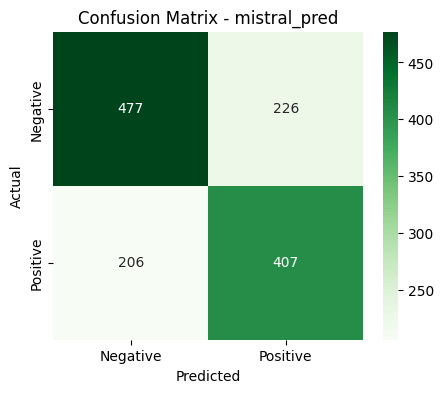

              precision    recall  f1-score   support

    negative       0.70      0.68      0.69       703
    positive       0.64      0.66      0.65       613

    accuracy                           0.67      1316
   macro avg       0.67      0.67      0.67      1316
weighted avg       0.67      0.67      0.67      1316


Confusion Matrix - tinyllama_pred
[[ 19 963]
 [ 13 840]]


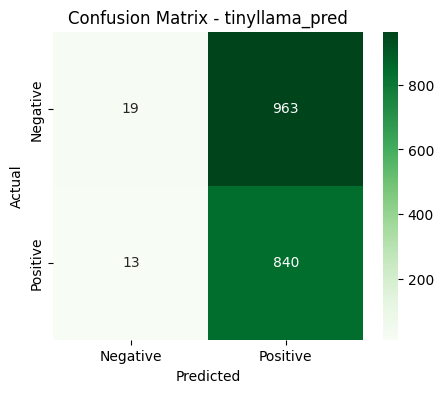

              precision    recall  f1-score   support

    negative       0.59      0.02      0.04       982
    positive       0.47      0.98      0.63       853

    accuracy                           0.47      1835
   macro avg       0.53      0.50      0.34      1835
weighted avg       0.53      0.47      0.31      1835


Confusion Matrix - phi3_pred
[[820 237]
 [611 324]]


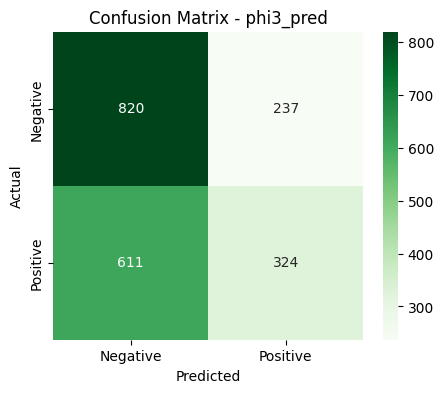

              precision    recall  f1-score   support

    negative       0.57      0.78      0.66      1057
    positive       0.58      0.35      0.43       935

    accuracy                           0.57      1992
   macro avg       0.58      0.56      0.55      1992
weighted avg       0.58      0.57      0.55      1992


Confusion Matrix - gemini_pred
[[134  28]
 [ 78  58]]


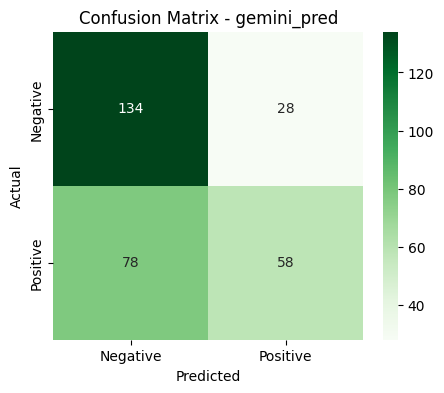

              precision    recall  f1-score   support

    negative       0.63      0.83      0.72       162
    positive       0.67      0.43      0.52       136

    accuracy                           0.64       298
   macro avg       0.65      0.63      0.62       298
weighted avg       0.65      0.64      0.63       298



In [ ]:
models = ["mistral_pred", "tinyllama_pred", "phi3_pred", "gemini_pred"]

for pred_col_name in models:

    print("\n=============================")
    print("Confusion Matrix -", pred_col_name)
    print("=============================")

    valid_predictions_mask = df_all[pred_col_name].notna()
    y_true_filtered = df_all.loc[valid_predictions_mask, "true_label"]
    y_pred_filtered = df_all.loc[valid_predictions_mask, pred_col_name]

    if not y_true_filtered.empty:
        cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=['negative', 'positive'])

        print(cm)

        plt.figure(figsize=(5,4))
        sns.heatmap(cm,
                    annot=True,
                    fmt="d",
                    cmap="Greens",
                    xticklabels=["Negative","Positive"],
                    yticklabels=["Negative","Positive"])

        plt.title(f"Confusion Matrix - {pred_col_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        print(classification_report(y_true_filtered, y_pred_filtered, labels=['negative', 'positive'], zero_division=0))
    else:
        print(f"No valid predictions for {pred_col_name} to compute confusion matrix and classification report.")

In [ ]:
confusion_matrix_data = []
sentiment_labels = ['negative', 'positive']

models_to_analyze = {
    "Mistral": "mistral_pred",
    "TinyLlama": "tinyllama_pred",
    "Phi-3": "phi3_pred",
    "Gemini": "gemini_pred"
}

for model_name, pred_col_name in models_to_analyze.items():
    valid_predictions_mask = df_all[pred_col_name].notna()
    y_true_filtered = df_all.loc[valid_predictions_mask, "true_label"]
    y_pred_filtered = df_all.loc[valid_predictions_mask, pred_col_name]

    valid_labels_mask = y_true_filtered.isin(sentiment_labels) & y_pred_filtered.isin(sentiment_labels)
    y_true_filtered_clean = y_true_filtered[valid_labels_mask]
    y_pred_filtered_clean = y_pred_filtered[valid_labels_mask]

    if not y_true_filtered_clean.empty:
        cm = confusion_matrix(y_true_filtered_clean, y_pred_filtered_clean, labels=sentiment_labels)
        # Confusion matrix is structured as:
        # [[TN, FP],
        #  [FN, TP]]
        tn, fp, fn, tp = cm.ravel()

        confusion_matrix_data.append({
            "Model": model_name,
            "True Negative (TN)": tn,
            "False Positive (FP)": fp,
            "False Negative (FN)": fn,
            "True Positive (TP)": tp
        })
    else:
        print(f"Skipping {model_name}: No valid 'negative' or 'positive' samples found after cleaning.")

cm_df = pd.DataFrame(confusion_matrix_data)
display(cm_df)

,Model,True Negative (TN),False Positive (FP),False Negative (FN),True Positive (TP)
0,Mistral,477,226,206,407
1,TinyLlama,19,963,13,840
2,Phi-3,820,237,611,324
3,Gemini,134,28,78,58


# 6. Time Performance Analysis

### Tier 4 Time Performance Analysis

In [ ]:
# --- TinyLlama Prediction Time ---
start_time_tinyllama = time.time()
df_all["tinyllama_pred_timed"] = df_all["text"].apply(
    lambda x: predict_llm(tok_tiny, mdl_tiny, x)
)
end_time_tinyllama = time.time()
elapsed_time_tinyllama = end_time_tinyllama - start_time_tinyllama
print(f"TinyLlama prediction time on {len(df_all)} samples: {elapsed_time_tinyllama:.2f} seconds")

# --- Phi-3 Prediction Time ---
start_time_phi3 = time.time()
df_all["phi3_pred_timed"] = df_all["text"].apply(
    lambda x: predict_llm(tok_phi, mdl_phi, x)
)
end_time_phi3 = time.time()
elapsed_time_phi3 = end_time_phi3 - start_time_phi3
print(f"Phi-3 prediction time on {len(df_all)} samples: {elapsed_time_phi3:.2f} seconds")

# --- Mistral Prediction Time ---
start_time_mistral = time.time()
df_all["mistral_pred_timed"] = df_all["text"].apply(predict_mistral_sentiment)
end_time_mistral = time.time()
elapsed_time_mistral = end_time_mistral - start_time_mistral
print(f"Mistral prediction time on {len(df_all)} samples: {elapsed_time_mistral:.2f} seconds")

TinyLlama prediction time on 2000 samples: 273.61 seconds
Phi-3 prediction time on 2000 samples: 434.53 seconds
Mistral prediction time on 2000 samples: 903.89 seconds


In [ ]:
# Note: Gemini latency includes mandatory sleep between API calls (rate-limit).

performance_data = [
    {
        "Model": "TinyLlama",
        "Samples": len(df_all),
        "Total Time (s)": elapsed_time_tinyllama,
        "Avg Time per Sample (s)": elapsed_time_tinyllama / len(df_all)
    },
    {
        "Model": "Phi-3",
        "Samples": len(df_all),
        "Total Time (s)": elapsed_time_phi3,
        "Avg Time per Sample (s)": elapsed_time_phi3 / len(df_all)
    },
    {
        "Model": "Mistral",
        "Samples": len(df_all),
        "Total Time (s)": elapsed_time_mistral,
        "Avg Time per Sample (s)": elapsed_time_mistral / len(df_all)
    },
    {
        "Model": "Gemini (API budget incl. sleep)",
        "Samples": N_SAMPLES,
        "Total Time (s)": SLEEP_S * N_SAMPLES,
        "Avg Time per Sample (s)": SLEEP_S
    }
]

performance_df = pd.DataFrame(performance_data)
print("\nModel Prediction Time Performance:")
performance_df



Model Prediction Time Performance:


,Model,Samples,Total Time (s),Avg Time per Sample (s)
0,TinyLlama,2000,273.613736,0.136807
1,Phi-3,2000,434.525269,0.217263
2,Mistral,2000,903.888752,0.451944
3,Gemini (API budget incl. sleep),300,600.000000,2.000000


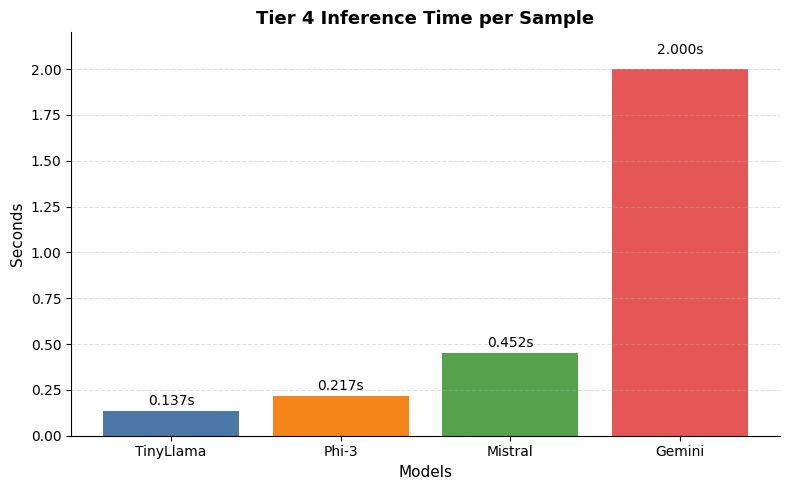

In [ ]:
df = pd.DataFrame({
    "Model": ["TinyLlama", "Phi-3", "Mistral", "Gemini"],
    "Latency": [0.136807, 0.217263, 0.451944, 2.000000]
})

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
plt.figure(figsize=(8, 5))
bars = plt.bar(df["Model"], df["Latency"], color=colors)
for bar in bars:
    height = bar.get_height()
    offset = 0.03 if height < 1 else 0.08
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + offset,
        f"{height:.3f}s",
        ha="center",
        fontsize=10
    )

plt.title(
    "Tier 4 Inference Time per Sample",
    fontsize=13,
    weight="bold"
)
plt.ylabel("Seconds", fontsize=11)
plt.xlabel("Models", fontsize=11)
plt.ylim(0, 2.2)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Tier 1 VADAR Time Performance Analysis

In [ ]:
df_test_sample = df_test.sample(n=10000, random_state=42).copy()

start_time_vader = time.time()
df_test_sample['VADER_Pred'] = df_test_sample['text'].apply(lambda x: analyze_vader(x).iloc[0]) # Re-run VADER prediction to measure time
end_time_vader = time.time()
elapsed_time_vader = end_time_vader - start_time_vader

print(f"VADER prediction time on {len(df_test_sample)} samples: {elapsed_time_vader:.2f} seconds")

vader_performance = pd.DataFrame([
    {
        "Model": "VADER",
        "Samples": len(df_test_sample),
        "Total Time (s)": elapsed_time_vader,
        "Avg Time per Sample (s)": elapsed_time_vader / len(df_test_sample)
    }
])

print("\nVADER Prediction Time Performance:")
display(vader_performance)

VADER prediction time on 10000 samples: 6.05 seconds

VADER Prediction Time Performance:


,Model,Samples,Total Time (s),Avg Time per Sample (s)
0,VADER,10000,6.051342,0.000605


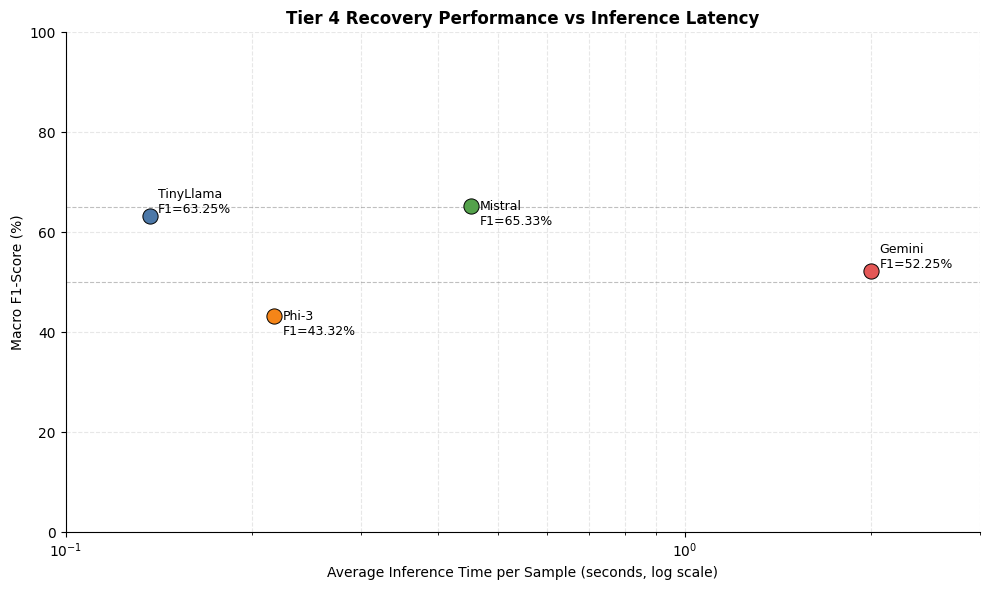

In [ ]:
df = pd.DataFrame({
    "Model": ["TinyLlama", "Phi-3", "Mistral", "Gemini"],
    "Latency_s": [0.136807, 0.217263, 0.451944, 2.000000],
    "F1_%": [63.25, 43.32, 65.33, 52.25]
})

color_map = {
    "TinyLlama": "#4C78A8",
    "Phi-3": "#F58518",
    "Mistral": "#54A24B",
    "Gemini": "#E45756"
}

plt.figure(figsize=(10, 6))
ax = plt.gca()
for _, row in df.iterrows():
    plt.scatter(
        row["Latency_s"],
        row["F1_%"],
        s=120,
        color=color_map[row["Model"]],
        edgecolor="black",
        linewidth=0.7,
        zorder=5
    )
offsets = {
    "TinyLlama": (6, 2),
    "Phi-3": (6, -14),
    "Mistral": (6, -14),
    "Gemini": (6, 2)
}
for _, row in df.iterrows():
    dx, dy = offsets[row["Model"]]
    plt.annotate(
        f"{row['Model']}\nF1={row['F1_%']:.2f}%",
        (row["Latency_s"], row["F1_%"]),
        textcoords="offset points",
        xytext=(dx, dy),
        fontsize=9
    )
for y in [50, 65]:
    plt.axhline(y=y, linestyle="--", linewidth=0.8, color="gray", alpha=0.5)
plt.xscale("log")
plt.xlim(0.1, 3)
plt.ylim(0, 100)
plt.xlabel("Average Inference Time per Sample (seconds, log scale)")
plt.ylabel("Macro F1-Score (%)")
plt.title("Tier 4 Recovery Performance vs Inference Latency", weight="bold")
plt.grid(True, which="both", linestyle="--", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()